# Notebook 04: Feature Engineering

   - Variables calendario cíclicas
   - Features de dominio
      1. Señales de presión
      2. Ciclo operacional
      3. Señales térmicas
      4. Señales eléctricas
   - Componentes STL como features
   - Lags de señales crudas y features de ingeniería
   - Etiqueta RUL

In [60]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import STL
import statsmodels.graphics.tsaplots as tsaplots
import os

sns.set_style('whitegrid')

ANALOG_COLS  = ['TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs',
                'Oil_temperature', 'Motor_current', 'Caudal_impulses']
BINARY_COLS  = ['COMP', 'DV_eletric', 'Towers', 'MPG', 'LPS',
                'Pressure_switch', 'Oil_level']

In [61]:
df = pd.read_parquet('../data/processed/df_operacion.parquet')
df['timestamp'] = pd.to_datetime(df['timestamp'])
print(f'Número de registros: {len(df):,}')
df

Número de registros: 114,740


,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses,id_segmento,regimen,id_sesion
0,2020-02-01 00:23:00,7.468667,8.511667,1.282667,-0.023333,8.509667,49.712500,5.740833,0.0,1.0,0.0,0.0,0.0,1.0,1.0,6.0,0,2,0
1,2020-02-01 00:24:00,8.343000,9.773000,1.671333,-0.023000,9.769333,49.854167,5.814167,0.0,1.0,1.0,0.0,0.0,1.0,1.0,6.0,0,2,0
2,2020-02-01 00:25:00,-0.020000,9.978333,9.970333,-0.022333,9.977000,51.975000,3.881667,1.0,0.0,1.0,1.0,0.0,1.0,1.0,6.0,0,1,0
3,2020-02-01 00:26:00,-0.013333,9.860667,9.847000,-0.022667,9.860667,53.654167,3.865833,1.0,0.0,1.0,1.0,0.0,1.0,1.0,6.0,0,1,0
4,2020-02-01 00:27:00,-0.012000,9.781000,9.766000,-0.022333,9.781000,53.241667,3.876250,1.0,0.0,1.0,1.0,0.0,1.0,1.0,6.0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114735,2020-09-01 03:49:00,-0.013667,9.817000,9.805000,-0.021667,9.816667,67.154167,3.887500,1.0,0.0,1.0,1.0,0.0,1.0,1.0,6.0,331,1,366
114736,2020-09-01 03:50:00,-0.012000,9.710333,9.696667,-0.021000,9.710000,65.625000,3.925000,1.0,0.0,1.0,1.0,0.0,1.0,1.0,6.0,331,1,366
114737,2020-09-01 03:51:00,-0.012000,9.612333,9.598333,-0.021000,9.612000,64.737500,3.863750,1.0,0.0,1.0,1.0,0.0,1.0,1.0,6.0,331,1,366
114738,2020-09-01 03:52:00,-0.012000,9.519000,9.505667,-0.021000,9.519000,64.541667,3.896250,1.0,0.0,1.0,1.0,0.0,1.0,1.0,6.0,331,1,366


## Variables calendario

In [62]:
df['hora_sin'] = np.sin(2 * np.pi * df['timestamp'].dt.hour / 24)
df['hora_cos'] = np.cos(2 * np.pi * df['timestamp'].dt.hour / 24)

df['dia_sin']  = np.sin(2 * np.pi * df['timestamp'].dt.dayofweek / 7)
df['dia_cos']  = np.cos(2 * np.pi * df['timestamp'].dt.dayofweek / 7)

df.head()

,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,...,Pressure_switch,Oil_level,Caudal_impulses,id_segmento,regimen,id_sesion,hora_sin,hora_cos,dia_sin,dia_cos
0,2020-02-01 00:23:00,7.468667,8.511667,1.282667,-0.023333,8.509667,49.712500,5.740833,0.0,1.0,...,1.0,1.0,6.0,0,2,0,0.0,1.0,-0.974928,-0.222521
1,2020-02-01 00:24:00,8.343000,9.773000,1.671333,-0.023000,9.769333,49.854167,5.814167,0.0,1.0,...,1.0,1.0,6.0,0,2,0,0.0,1.0,-0.974928,-0.222521
2,2020-02-01 00:25:00,-0.020000,9.978333,9.970333,-0.022333,9.977000,51.975000,3.881667,1.0,0.0,...,1.0,1.0,6.0,0,1,0,0.0,1.0,-0.974928,-0.222521
3,2020-02-01 00:26:00,-0.013333,9.860667,9.847000,-0.022667,9.860667,53.654167,3.865833,1.0,0.0,...,1.0,1.0,6.0,0,1,0,0.0,1.0,-0.974928,-0.222521
4,2020-02-01 00:27:00,-0.012000,9.781000,9.766000,-0.022333,9.781000,53.241667,3.876250,1.0,0.0,...,1.0,1.0,6.0,0,1,0,0.0,1.0,-0.974928,-0.222521


Registros en últimas 48h: 4370
De: 2020-08-25 04:03:00
A:  2020-09-01 03:53:00


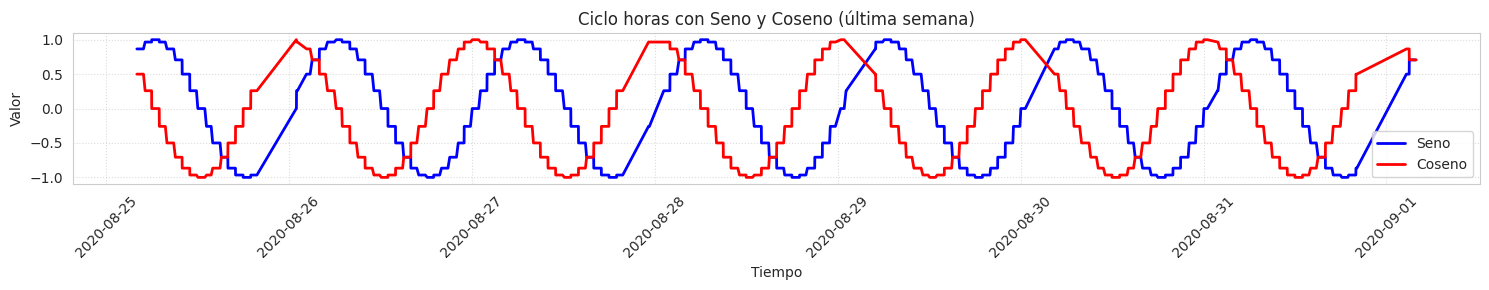

In [63]:
ts_fin   = df['timestamp'].max()
ts_inicio = ts_fin - pd.Timedelta(hours=168)

df_168 = df[
    (df['timestamp'] >= ts_inicio) &
    (df['timestamp'] <= ts_fin)
].copy()

print(f"Registros en últimas 48h: {len(df_168)}")
print(f"De: {df_168['timestamp'].min()}")
print(f"A:  {df_168['timestamp'].max()}")

plt.figure(figsize=(15, 3))
plt.plot(df_168['timestamp'], df_168['hora_sin'], label='Seno', color='blue', linewidth=2)
plt.plot(df_168['timestamp'], df_168['hora_cos'], label='Coseno', color='red', linewidth=2)

plt.xlabel('Tiempo')
plt.ylabel('Valor')
plt.title('Ciclo horas con Seno y Coseno (última semana)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.xticks(rotation=45)
plt.ylim(-1.1, 1.1)
plt.tight_layout()
plt.show()

Registro del último mes
De   : 2020-08-04 03:53:00
Hasta: 2020-09-01 03:52:00


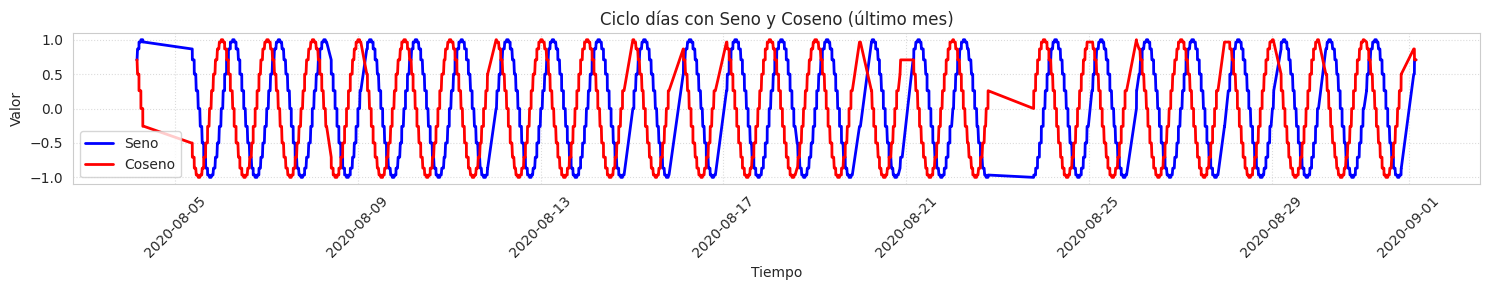

In [64]:
ts_fin = df['timestamp'].max()
ts_inicio = ts_fin - pd.Timedelta(weeks = 4)

df_month = df[
    (df['timestamp'] >= ts_inicio) &
    (df['timestamp'] < ts_fin)
]

print('Registro del último mes')
print(f"De   : {df_month['timestamp'].min()}")
print(f"Hasta: {df_month['timestamp'].max()}")

plt.figure(figsize=(15, 3))
plt.plot(df_month['timestamp'], df_month['hora_sin'], label='Seno', color='blue', linewidth=2)
plt.plot(df_month['timestamp'], df_month['hora_cos'], label='Coseno', color='red', linewidth=2)

plt.xlabel('Tiempo')
plt.ylabel('Valor')
plt.title('Ciclo días con Seno y Coseno (último mes)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.xticks(rotation=45)
plt.ylim(-1.1, 1.1)
plt.tight_layout()
plt.show()

## Features de dominio

### 1. Señales de Presión

In [65]:
df['delta_presion'] = df['TP3'] - df['Reservoirs']
df['TP2-TP3'] = df['TP2'] - df['TP3']

### 2. Ciclo operacional


In [66]:
# df['ratio_sin_carga_60min'] = df['regimen'].eq(1).rolling(60).mean()
df['ratio_con_carga_60min'] = df['regimen'].eq(2).rolling(60).mean()

### 3. Señales térmicas

In [67]:
df['cambio_Oil_temperature_X_ciclo'] = df['Oil_temperature'].diff(9)
df['cambio_Oil_temperature_X_mediah'] = df['Oil_temperature'].diff(30)
df['cambio_Oil_temperature_X_h'] = df['Oil_temperature'].diff(60)
df['Oil_temperature_zscore'] = df.groupby('id_sesion')['Oil_temperature'].transform(lambda x: (x - x.mean())/ x.std())

In [68]:
df.tail()

,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,...,hora_cos,dia_sin,dia_cos,delta_presion,TP2-TP3,ratio_con_carga_60min,cambio_Oil_temperature_X_ciclo,cambio_Oil_temperature_X_mediah,cambio_Oil_temperature_X_h,Oil_temperature_zscore
114735,2020-09-01 03:49:00,-0.013667,9.817000,9.805000,-0.021667,9.816667,67.154167,3.887500,1.0,0.0,...,0.707107,0.781831,0.62349,0.000333,-9.830667,0.2,1.141667,0.770833,-4.687500,1.445192
114736,2020-09-01 03:50:00,-0.012000,9.710333,9.696667,-0.021000,9.710000,65.625000,3.925000,1.0,0.0,...,0.707107,0.781831,0.62349,0.000333,-9.722333,0.2,0.995833,-0.808333,-4.133333,1.060808
114737,2020-09-01 03:51:00,-0.012000,9.612333,9.598333,-0.021000,9.612000,64.737500,3.863750,1.0,0.0,...,0.707107,0.781831,0.62349,0.000333,-9.624333,0.2,0.962500,-1.733333,-3.095833,0.837719
114738,2020-09-01 03:52:00,-0.012000,9.519000,9.505667,-0.021000,9.519000,64.541667,3.896250,1.0,0.0,...,0.707107,0.781831,0.62349,0.000000,-9.531000,0.2,1.395833,5.122917,-2.379167,0.788493
114739,2020-09-01 03:53:00,-0.012333,9.427667,9.415000,-0.021667,9.428333,64.791667,3.845417,1.0,0.0,...,0.707107,0.781831,0.62349,-0.000667,-9.440000,0.2,1.575000,5.458333,-2.095833,0.851335


### 4. Señales eléctricas

## Componentes STL Tendencia y estacionalidad

## Lags de las originales y las de ingeniería

## Asignar una etiqueta RUL basandome en el RUL_MAX = 24 Hrs.


### 1. Cargar df_op (datos operacionales)

### 2. Variables calendario (antes del filtrado ya están en df_op porque se calcularon en preprocesamiento) Si no: hora_sin, hora_cos, dia_sin, dia_cos

### 3. Features de dominio delta_presion, ratio_carga, frecuencia_LPS, temp_rate

### 4. Componentes STL Por sesión → tendencia y residuo de señales crudas Y de features de dominio

### 5. Etiqueta RUL Calcular sobre timestamps reales

### 6. Lags de TODO lo anterior Señales crudas + features dominio + componentes STL Dentro de cada sesión

### 7. Features estadísticas de ventana media, std en ventanas de 15, 30, 60 min

### 8. Guardar dataset final